# Laboratorio 7
## Regresión Logística

1. Cree una variable dicotómica por cada una de las categorías de la variable respuesta categórica que creó en hojas anteriores. Debería tener 3 variables dicotómicas (valores 0 y 1) una que diga si el airbnb es caro o no, medio o no, económico o no.

2. Use los mismos conjuntos de entrenamiento y prueba que utilizó en las hojas anteriores.

3. Elabore un modelo de regresión logística para conocer si una vivienda es cara o no, utilizando el conjunto de entrenamiento y explique los resultados a los que llega. El experimento debe ser reproducible por lo que debe fijar que los conjuntos de entrenamiento y prueba sean los mismos siempre que se ejecute el código. Use validación cruzada. Ponga el umbral de decisión en 0.5.

In [16]:
# PREPARACIÓN DEL ENTORNO Y CARGA DE DATOS (Siguiendo del Laboratorio 6)

import importlib, subprocess, sys

# Asegurar librerías necesarias
required = {"pandas": "pandas", "numpy": "numpy", "sklearn": "scikit-learn", "pyreadr": "pyreadr", "matplotlib":"matplotlib", "seaborn":"seaborn", "statsmodels":"statsmodels"}
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

print("FASE 1: CARGA Y PREPARACIÓN DE DATOS")
# Cargar el dataset
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Limpieza de precio
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_model = df.loc[df['price'].notna() & (df['price'] > 0)].copy()

# Creación de la variable categórica (barata, intermedia, cara)
limites = df_model['price'].quantile([0.33, 0.66]).values
p33, p66 = limites[0], limites[1]

def definir_segmento(precio):
    if precio <= p33: return 'Económica'
    elif precio <= p66: return 'Intermedia'
    else: return 'Cara'

df_model['categoria_precio'] = df_model['price'].apply(definir_segmento)

# Selección de predictores y manejo de nulos/dummies
features_clas = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
for col in features_clas:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

X_clas = df_model[features_clas].copy()
if 'room_type' in df_model.columns:
    room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
    X_clas = pd.concat([X_clas, room_type_dummies], axis=1)

X_clas = X_clas.fillna(X_clas.median(numeric_only=True))

# División Train/Test MANTENIENDO LA SEMILLA 42
X_train_c, X_test_c, _, _ = train_test_split(X_clas, df_model['categoria_precio'], test_size=0.2, random_state=42)

# Escalado de datos
scaler_clas = StandardScaler()
X_train_c_scaled = scaler_clas.fit_transform(X_train_c)
X_test_c_scaled = scaler_clas.transform(X_test_c)

print("Datos cargados, limpios y escalados correctamente.\n")

FASE 1: CARGA Y PREPARACIÓN DE DATOS
Datos cargados, limpios y escalados correctamente.



In [17]:
# INICIO LABORATORIO 7: REGRESIÓN LOGÍSTICA

print("FASE 2: LABORATORIO 7")


# Actividad 1: Creación de variables dicotómicas

print("\nActividad 1: Variables dicotómicas")
df_model['es_cara'] = (df_model['categoria_precio'] == 'Cara').astype(int)
df_model['es_intermedia'] = (df_model['categoria_precio'] == 'Intermedia').astype(int)
df_model['es_economica'] = (df_model['categoria_precio'] == 'Económica').astype(int)

print("Distribución de 'es_cara':")
print((df_model['es_cara'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# Actividad 2: Mismos conjuntos de entrenamiento y prueba

print("\nActividad 2: Reutilizando splits")
y_train_cara = df_model.loc[X_train_c.index, 'es_cara'].copy()
y_test_cara = df_model.loc[X_test_c.index, 'es_cara'].copy()

print(f"Filas en entrenamiento: {y_train_cara.shape[0]}")
print(f"Filas en prueba: {y_test_cara.shape[0]}")

# Actividad 3: Modelo de Regresión Logística (Cara vs No Cara)

print("\nActividad 3: Entrenamiento y Validación Cruzada")
log_reg_cara = LogisticRegression(random_state=42, max_iter=1000)

cv_scores = cross_val_score(log_reg_cara, X_train_c_scaled, y_train_cara, cv=5, scoring='accuracy')
print(f"Accuracy en Validación Cruzada (media): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

log_reg_cara.fit(X_train_c_scaled, y_train_cara)
y_pred_train_cara = log_reg_cara.predict(X_train_c_scaled)

print("\nReporte de Clasificación sobre Entrenamiento (Umbral 0.5):")
print(classification_report(y_train_cara, y_pred_train_cara))

FASE 2: LABORATORIO 7

Actividad 1: Variables dicotómicas
Distribución de 'es_cara':
es_cara
0    66.03%
1    33.97%
Name: proportion, dtype: str

Actividad 2: Reutilizando splits
Filas en entrenamiento: 60996
Filas en prueba: 15250

Actividad 3: Entrenamiento y Validación Cruzada
Accuracy en Validación Cruzada (media): 0.7776 (+/- 0.0026)

Reporte de Clasificación sobre Entrenamiento (Umbral 0.5):
              precision    recall  f1-score   support

           0       0.80      0.89      0.84     40240
           1       0.73      0.56      0.63     20756

    accuracy                           0.78     60996
   macro avg       0.76      0.72      0.74     60996
weighted avg       0.77      0.78      0.77     60996



Gráficas para visualización


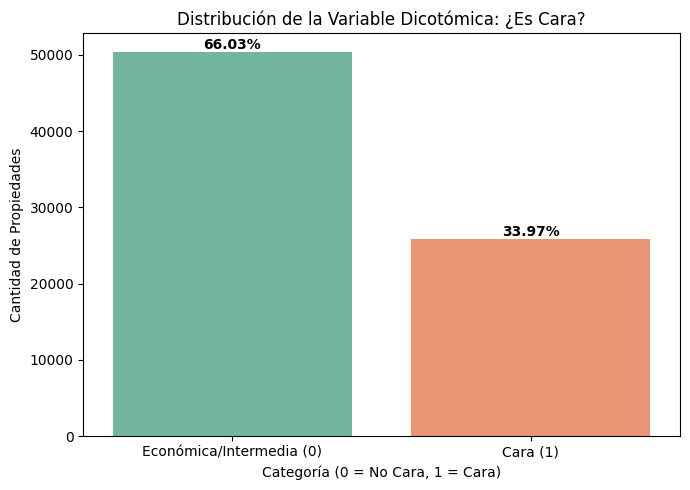

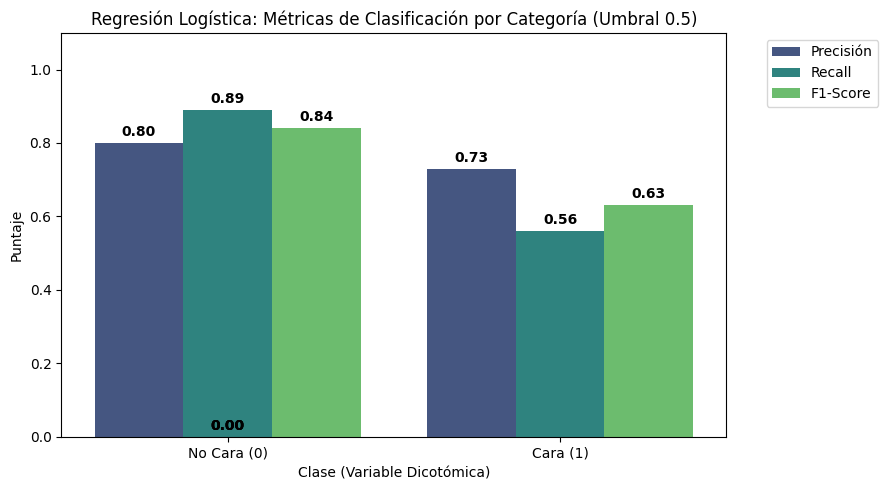

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Gráficas para visualización")

# Gráfica 1: Distribución de la variable 'es_cara'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_model, x='es_cara', hue='es_cara', palette='Set2', legend=False)
plt.title('Distribución de la Variable Dicotómica: ¿Es Cara?')
plt.xlabel('Categoría (0 = No Cara, 1 = Cara)')
plt.ylabel('Cantidad de Propiedades')
plt.xticks(ticks=[0, 1], labels=['Económica/Intermedia (0)', 'Cara (1)'])

# Añadir porcentajes sobre las barras
total = len(df_model)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# Gráfica 2: Métricas de Clasificación (Entrenamiento)

# Extraemos los datos del reporte
metricas = {
    'Clase': ['No Cara (0)', 'No Cara (0)', 'No Cara (0)', 'Cara (1)', 'Cara (1)', 'Cara (1)'],
    'Métrica': ['Precisión', 'Recall', 'F1-Score', 'Precisión', 'Recall', 'F1-Score'],
    'Puntaje': [0.80, 0.89, 0.84, 0.73, 0.56, 0.63]
}
df_metricas = pd.DataFrame(metricas)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_metricas, x='Clase', y='Puntaje', hue='Métrica', palette='viridis')
plt.title('Regresión Logística: Métricas de Clasificación por Categoría (Umbral 0.5)')
plt.ylim(0, 1.1)
plt.xlabel('Clase (Variable Dicotómica)')
plt.ylabel('Puntaje')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir etiquetas de datos
ax2 = plt.gca()
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.2f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), 
                 textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

4. Analice el modelo. Determine si hay multicolinealidad en las variables, y cuáles son las que aportan al modelo, por su valor de significación. Haga un análisis de correlación de las variables del modelo y especifique si el modelo se adapta bien a los datos. 

Actividad 4: Análisis del modelo

A. Generando Matriz de Correlación...


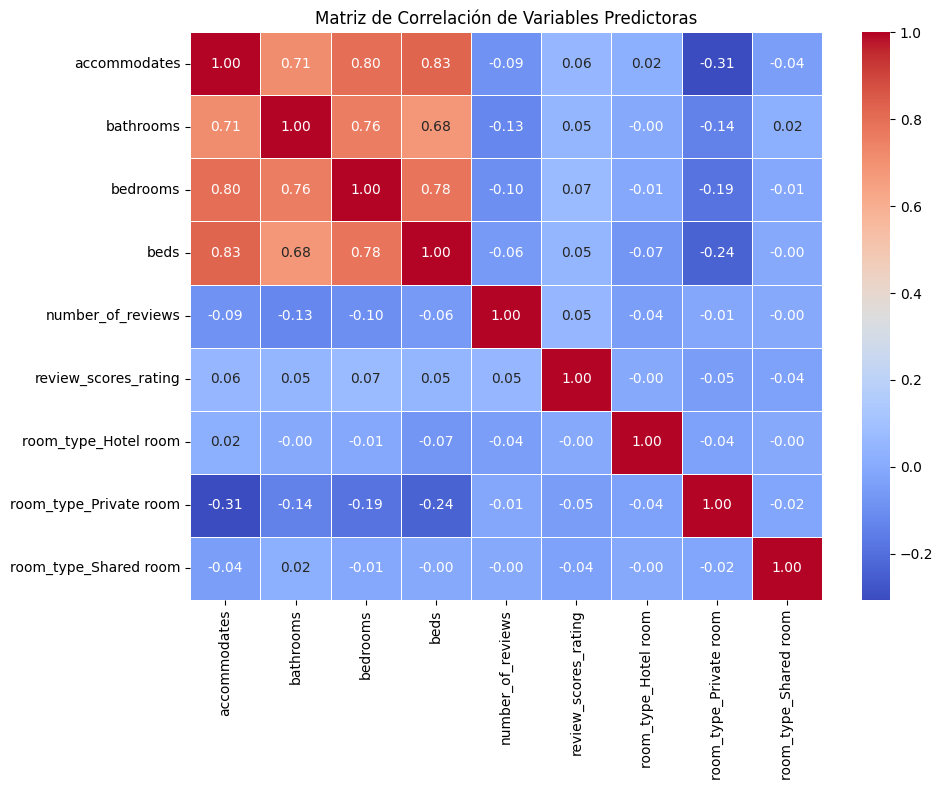


B. Factor de Inflación de Varianza (VIF):
              Variable      VIF
          accommodates 4.333916
              bedrooms 3.825079
                  beds 3.765465
             bathrooms 2.602945
room_type_Private room 1.126660
  room_type_Hotel room 1.028430
     number_of_reviews 1.024840
 room_type_Shared room 1.011477
  review_scores_rating 1.010740

C. Resumen Estadístico del Modelo (Statsmodels):

=== Coeficientes y Significancia (P-values) ===
                           Coef.          P>|z|
constante              -0.803695   0.000000e+00
accommodates            0.710391  1.004800e-172
bathrooms               0.767180   0.000000e+00
bedrooms               -0.027711   1.819214e-01
beds                    0.156112   2.021574e-10
number_of_reviews      -0.531953  1.155789e-226
review_scores_rating    0.235323   4.899041e-73
room_type_Hotel room    0.230679   2.511617e-99
room_type_Private room -0.045269   2.178403e-04
room_type_Shared room  -0.335381   7.329767e-20

Pseudo R-

In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

print("Actividad 4: Análisis del modelo")

# A. Análisis de Correlación
print("\nA. Generando Matriz de Correlación...")
plt.figure(figsize=(10, 8))
# Usamos las variables originales para ver la correlación lineal entre ellas
correlacion = X_train_c.corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Variables Predictoras")
plt.tight_layout()
plt.show()

# B. Análisis de Multicolinealidad (VIF)
print("\nB. Factor de Inflación de Varianza (VIF):")
# Forzamos predictores numéricos y limpiamos valores no finitos antes de calcular VIF
X_train_vif = X_train_c.apply(pd.to_numeric, errors='coerce').copy()
X_train_vif = X_train_vif.replace([np.inf, -np.inf], np.nan)
X_train_vif = X_train_vif.fillna(X_train_vif.median(numeric_only=True))
X_train_vif = sm.add_constant(X_train_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_vif.columns
exog_vif = X_train_vif.astype(float).values
vif_data["VIF"] = [variance_inflation_factor(exog_vif, i) for i in range(X_train_vif.shape[1])]
# Filtramos la constante para mostrar solo el VIF de nuestras variables
vif_data = vif_data[vif_data["Variable"] != "const"].sort_values(by="VIF", ascending=False)
print(vif_data.to_string(index=False))

# C. Significancia de las variables (p-values) y bondad de ajuste
print("\nC. Resumen Estadístico del Modelo (Statsmodels):")
# Para la regresión logística en statsmodels, usamos los datos escalados (para ayudar a la convergencia)
X_train_sm = sm.add_constant(X_train_c_scaled)
# Renombramos las columnas para que el resumen sea fácil de leer
columnas = ['constante'] + list(X_train_c.columns)
X_train_sm = pd.DataFrame(X_train_sm, columns=columnas)

# Ajustamos el modelo Logit
try:
    # Usamos list(y_train_cara) para evitar problemas de índices con statsmodels
    logit_model = sm.Logit(list(y_train_cara), X_train_sm)
    result = logit_model.fit(disp=0)  # disp=0 evita que imprima el log de iteraciones
    
    print("\n=== Coeficientes y Significancia (P-values) ===")
    print(result.summary2().tables[1][['Coef.', 'P>|z|']])
    print(f"\nPseudo R-squared (McFadden): {result.prsquared:.4f}")
    print(f"LLR p-value (Significancia global): {result.llr_pvalue:.4e}")
except Exception as e:
    print("Hubo un error al ajustar el modelo estadístico:", e)

5. Utilice el modelo con el conjunto de prueba y determine la eficiencia del algoritmo para clasificar.

6. Explique si hay sobreajuste (overfitting) o no (recuerde usar para esto los errores del conjunto de prueba
y de entrenamiento). Muestre las curvas de aprendizaje usando los errores de los conjuntos de
entrenamiento y prueba.

ACTIVIDAD 5 Y 6

Actividad 5: Evaluación en el Conjunto de Prueba (Umbral 0.5)
Accuracy Global en Prueba: 0.7790

Reporte de Clasificación (Prueba):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84     10109
           1       0.72      0.57      0.64      5141

    accuracy                           0.78     15250
   macro avg       0.76      0.73      0.74     15250
weighted avg       0.77      0.78      0.77     15250



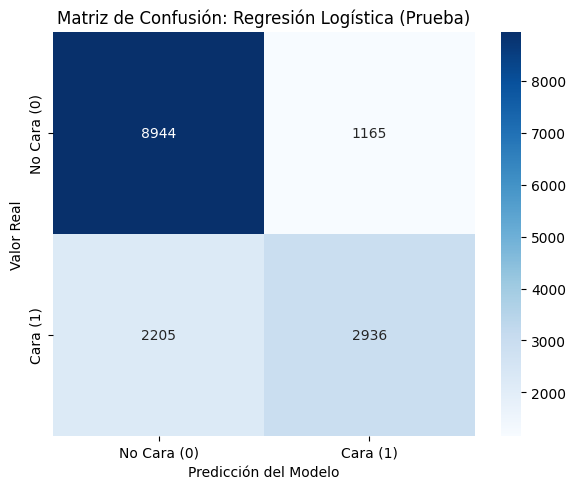


Actividad 6: Análisis de Sobreajuste (Train vs Test)
Accuracy en Entrenamiento: 0.7779
Accuracy en Prueba:        0.7790
Diferencia (Gap):          -0.0011

Generando Curva de Aprendizaje...


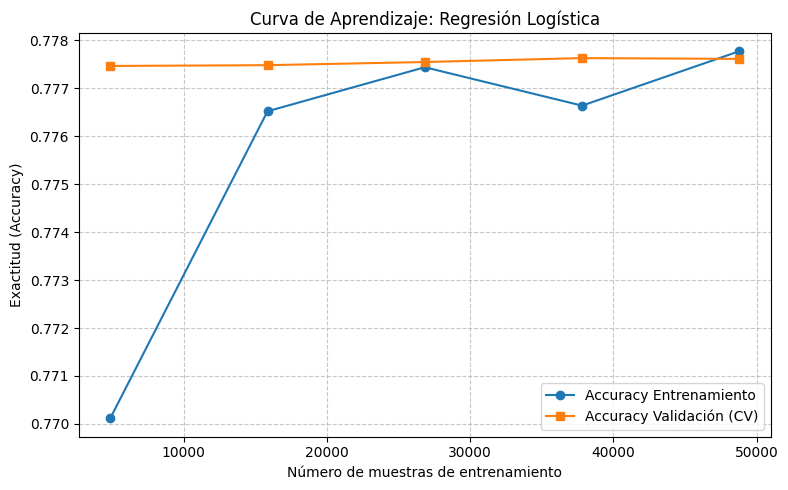

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve
import numpy as np

print("ACTIVIDAD 5 Y 6")

# Actividad 5: Evaluación en el Conjunto de Prueba

print("\nActividad 5: Evaluación en el Conjunto de Prueba (Umbral 0.5)")
# Predicciones sobre el conjunto de prueba
y_pred_test_cara = log_reg_cara.predict(X_test_c_scaled)

acc_test = accuracy_score(y_test_cara, y_pred_test_cara)
print(f"Accuracy Global en Prueba: {acc_test:.4f}")

print("\nReporte de Clasificación (Prueba):")
print(classification_report(y_test_cara, y_pred_test_cara))

# Matriz de confusión
cm = confusion_matrix(y_test_cara, y_pred_test_cara)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Cara (0)', 'Cara (1)'], 
            yticklabels=['No Cara (0)', 'Cara (1)'])
plt.title('Matriz de Confusión: Regresión Logística (Prueba)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# Actividad 6: Análisis de Sobreajuste y Curva de Aprendizaje

print("\nActividad 6: Análisis de Sobreajuste (Train vs Test)")
# Extraemos el accuracy de entrenamiento calculado en la Actividad 3
y_pred_train_cara = log_reg_cara.predict(X_train_c_scaled)
acc_train = accuracy_score(y_train_cara, y_pred_train_cara)

print(f"Accuracy en Entrenamiento: {acc_train:.4f}")
print(f"Accuracy en Prueba:        {acc_test:.4f}")
print(f"Diferencia (Gap):          {acc_train - acc_test:.4f}")

print("\nGenerando Curva de Aprendizaje...")
# Generamos la curva iterando sobre distintos tamaños del set de entrenamiento
train_sizes, train_scores, test_scores = learning_curve(
    estimator=log_reg_cara,
    X=X_train_c_scaled,
    y=y_train_cara,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, color='#1f77b4', marker='o', label='Accuracy Entrenamiento')
plt.plot(train_sizes, test_mean, color='#ff7f0e', marker='s', label='Accuracy Validación (CV)')
plt.title('Curva de Aprendizaje: Regresión Logística')
plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('Exactitud (Accuracy)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

7. Haga un tuneo del modelo para determinar los mejores parámetros, recuerde que los modelos de
regresión logística se pueden regularizar como los de regresión lineal. Use
8. Haga un análisis de la eficiencia del algoritmo usando una matriz de confusión. Tenga en cuenta la
efectividad, donde el algoritmo se equivocó más, donde se equivocó menos y la importancia que tienen
los errores, el tiempo y la memoria consumida. Para esto último puede usar “profvis” si trabaja con R y
“cProfile” en Python.
9. ¿El umbral de decisión en 0.5 es lo mejor para este conjunto de datos? Pruebe con otros umbrales de
decisión. Apóyese en el índice de Youden para determinar el umbral que le de más balance entre la
especificidad y la sensibilidad. Use la sensibilidad, especificidad y la importancia de los errores para
justificar su decisión. Cree una nueva matriz de confusión y compárela con la del modelo con umbral de
decisión en 0.5.
10. Determine cual de todos los modelos es mejor, puede usar AIC y BIC para esto, además de los parámetros
de la matriz de confusión y los del profiler.
11. Haga un modelo de regresión logística para la variable categórica para el precio de las casas (categorías:
barata, media y cara). Asegúrese de tunearlo para obtener el mejor modelo posible.
12. Compare la eficiencia del modelo anterior con los de clasificación de las entregas anteriores ¿Cuál se
demoró más en procesar?¿Cuál se equivocó más?¿Cuál se equivocó menos?¿por qué?

--- Actividad 7: TUNEO DE HIPERPARÁMETROS ---
Mejores parámetros: {'C': 0.01, 'solver': 'lbfgs'}
Mejor Accuracy en CV: 0.7777

--- Actividad 8: PROFILER Y MATRIZ DE CONFUSIÓN ---
Estadísticas de tiempo (cProfile):
         319 function calls in 0.001 seconds

   Ordered by: cumulative time
   List reduced from 110 to 3 due to restriction <3>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        4    0.000    0.000    0.001    0.000 c:\Users\jmo\Documents\MineriaDeDatos\Laboratorio7Mineria\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3711(run_code)
        4    0.000    0.000    0.001    0.000 {built-in method builtins.exec}
        1    0.000    0.000    0.001    0.001 c:\Users\jmo\Documents\MineriaDeDatos\Laboratorio7Mineria\.venv\Lib\site-packages\sklearn\linear_model\_base.py:372(predict)




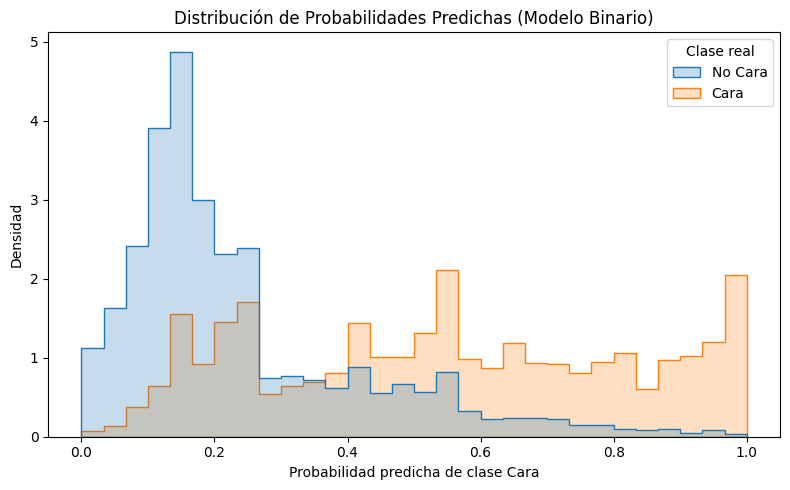


--- Actividad 9: UMBRAL DE DECISIÓN (YOUDEN) ---
AUC ROC: 0.8249
Mejor Umbral (Índice de Youden): 0.3387
Sensibilidad en este umbral: 0.7296
Especificidad en este umbral: 0.7780


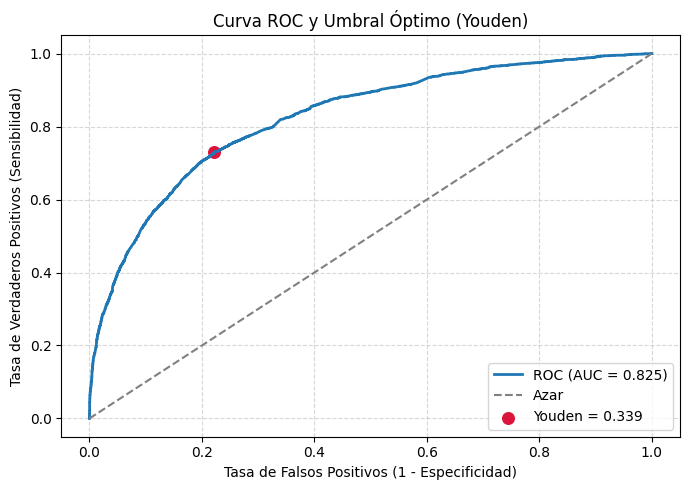

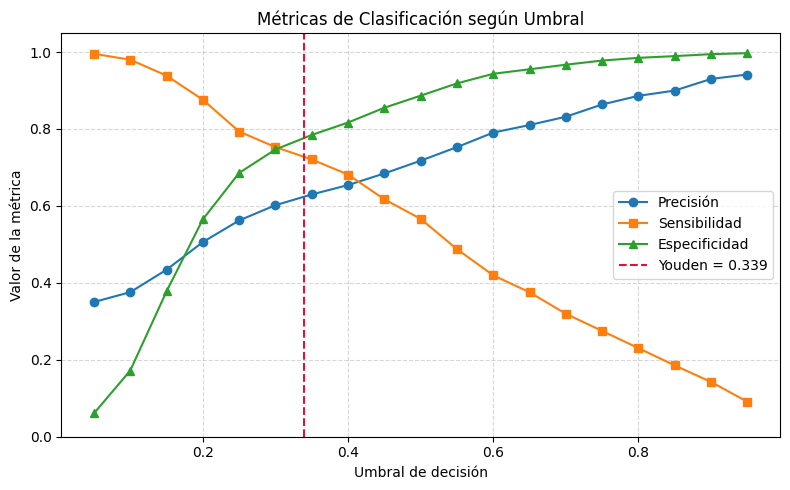


Reporte con Umbral Youden:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81     10109
           1       0.63      0.73      0.67      5141

    accuracy                           0.76     15250
   macro avg       0.74      0.75      0.74     15250
weighted avg       0.77      0.76      0.77     15250



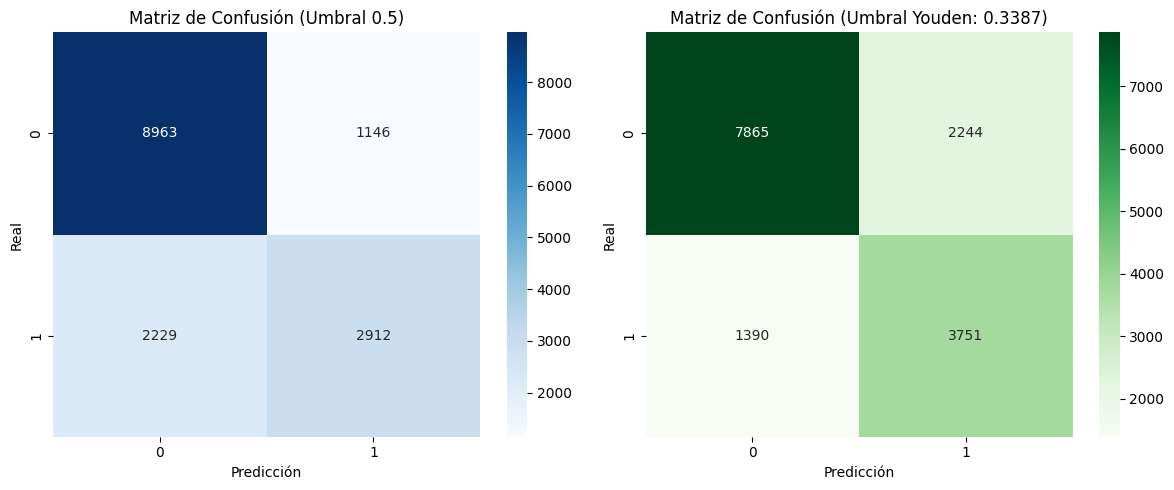


--- Actividad 10: AIC / BIC ---
AIC del modelo logístico: 58426.20
BIC del modelo logístico: 58516.38

Actividad 11 y 12: REGRESIÓN LOGÍSTICA MULTINOMIAL (3 CLASES)
Mejores parámetros Multinomial: {'C': 0.1}
Accuracy Multinomial en Prueba: 0.5902
Tiempo de procesamiento (Tuneo + Fit Multinomial): 0.49 segundos

Reporte de Clasificación Multinomial:
              precision    recall  f1-score   support

        Cara       0.65      0.69      0.67      5141
   Económica       0.62      0.65      0.64      4983
  Intermedia       0.48      0.43      0.46      5126

    accuracy                           0.59     15250
   macro avg       0.58      0.59      0.59     15250
weighted avg       0.58      0.59      0.59     15250



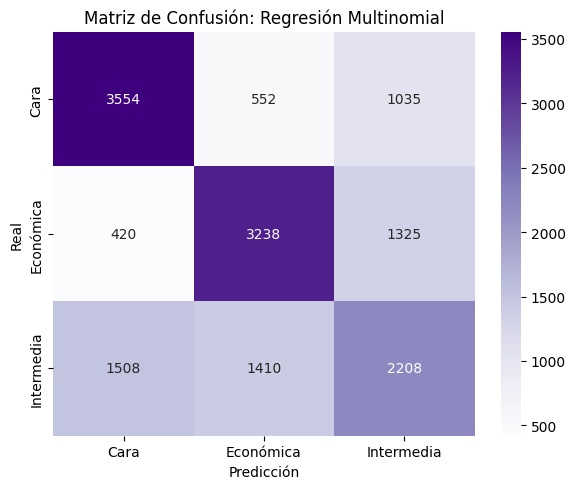

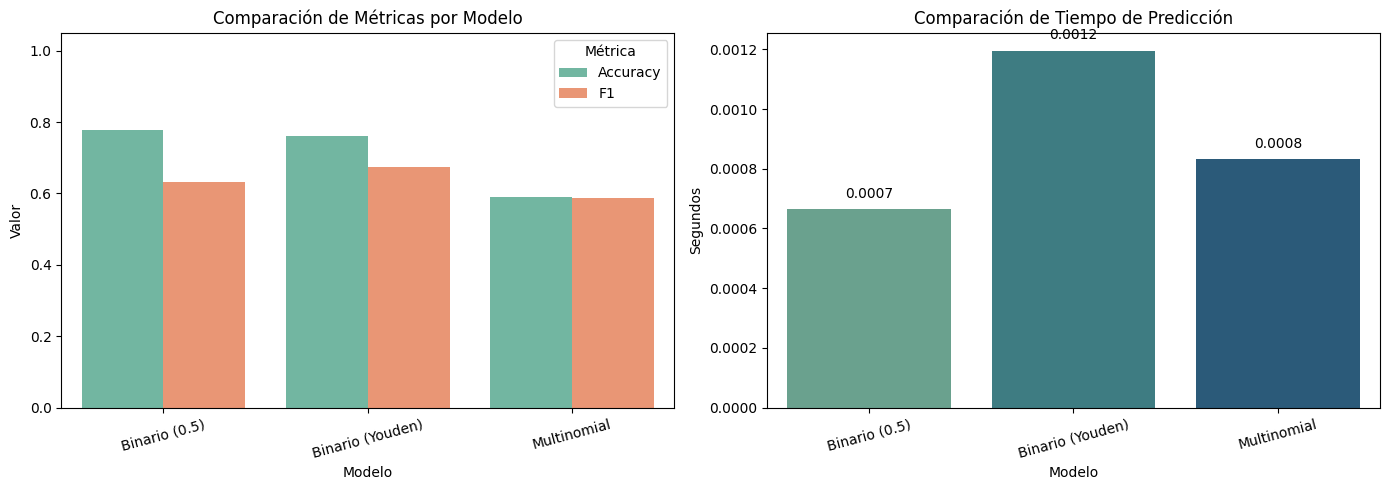


Resumen comparativo para Actividad 12:
          Modelo  Accuracy       F1
   Binario (0.5)  0.778689 0.633112
Binario (Youden)  0.761705 0.673671
     Multinomial  0.590164 0.586872

Tiempos de predicción (segundos):
          Modelo  Tiempo (s)
   Binario (0.5)    0.000666
Binario (Youden)    0.001195
     Multinomial    0.000832


In [21]:
import cProfile
import pstats
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
 )
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

print("--- Actividad 7: TUNEO DE HIPERPARÁMETROS ---")
# Probaremos distintos niveles de regularización (C)
param_grid = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs']}
grid_log = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_log.fit(X_train_c_scaled, y_train_cara)

best_log_reg = grid_log.best_estimator_
print(f"Mejores parámetros: {grid_log.best_params_}")
print(f"Mejor Accuracy en CV: {grid_log.best_score_:.4f}")

print("\n--- Actividad 8: PROFILER Y MATRIZ DE CONFUSIÓN ---")
# Usamos cProfile para medir tiempo de predicción del modelo binario (umbral 0.5)
profiler = cProfile.Profile()
profiler.enable()
inicio_pred_bin = time.perf_counter()
y_pred_best = best_log_reg.predict(X_test_c_scaled)
tiempo_pred_bin = time.perf_counter() - inicio_pred_bin
profiler.disable()

print("Estadísticas de tiempo (cProfile):")
stats = pstats.Stats(profiler).sort_stats('cumtime')
stats.print_stats(3)  # Imprime las 3 líneas más importantes

cm_best = confusion_matrix(y_test_cara, y_pred_best)

# Gráfica distribución de probabilidades predichas por clase real
y_prob_base = best_log_reg.predict_proba(X_test_c_scaled)[:, 1]
df_prob = pd.DataFrame({
    'Probabilidad de ser Cara': y_prob_base,
    'Clase real': y_test_cara.map({0: 'No Cara', 1: 'Cara'})
})
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_prob,
    x='Probabilidad de ser Cara',
    hue='Clase real',
    bins=30,
    stat='density',
    common_norm=False,
    element='step'
 )
plt.title('Distribución de Probabilidades Predichas (Modelo Binario)')
plt.xlabel('Probabilidad predicha de clase Cara')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()

print("\n--- Actividad 9: UMBRAL DE DECISIÓN (YOUDEN) ---")
# Obtenemos probabilidades para calcular curva ROC
y_prob = y_prob_base
fpr, tpr, thresholds = roc_curve(y_test_cara, y_prob)
auc_roc = roc_auc_score(y_test_cara, y_prob)

# Índice de Youden = Sensibilidad (TPR) + Especificidad (1 - FPR) - 1
youden_index = tpr - fpr
best_threshold_idx = np.argmax(youden_index)
best_threshold = thresholds[best_threshold_idx]

print(f"AUC ROC: {auc_roc:.4f}")
print(f"Mejor Umbral (Índice de Youden): {best_threshold:.4f}")
print(f"Sensibilidad en este umbral: {tpr[best_threshold_idx]:.4f}")
print(f"Especificidad en este umbral: {1 - fpr[best_threshold_idx]:.4f}")

# Gráfica Curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f'ROC (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
plt.scatter(
    fpr[best_threshold_idx],
    tpr[best_threshold_idx],
    color='crimson',
    s=70,
    label=f'Youden = {best_threshold:.3f}'
 )
plt.title('Curva ROC y Umbral Óptimo (Youden)')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfica Métricas vs umbral
threshold_grid = np.linspace(0.05, 0.95, 19)
precision_vals, sensibilidad_vals, especificidad_vals = [], [], []
for thr in threshold_grid:
    y_pred_thr = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_cara, y_pred_thr).ravel()
    precision_vals.append(precision_score(y_test_cara, y_pred_thr, zero_division=0))
    sensibilidad_vals.append(recall_score(y_test_cara, y_pred_thr, zero_division=0))
    especificidad_vals.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

plt.figure(figsize=(8, 5))
plt.plot(threshold_grid, precision_vals, marker='o', label='Precisión')
plt.plot(threshold_grid, sensibilidad_vals, marker='s', label='Sensibilidad')
plt.plot(threshold_grid, especificidad_vals, marker='^', label='Especificidad')
plt.axvline(best_threshold, color='crimson', linestyle='--', label=f'Youden = {best_threshold:.3f}')
plt.title('Métricas de Clasificación según Umbral')
plt.xlabel('Umbral de decisión')
plt.ylabel('Valor de la métrica')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Predicciones con el nuevo umbral (tiempo de inferencia real con predict_proba + regla de corte)
inicio_pred_youden = time.perf_counter()
y_prob_youden = best_log_reg.predict_proba(X_test_c_scaled)[:, 1]
y_pred_youden = (y_prob_youden >= best_threshold).astype(int)
tiempo_pred_youden = time.perf_counter() - inicio_pred_youden
cm_youden = confusion_matrix(y_test_cara, y_pred_youden)

print("\nReporte con Umbral Youden:")
print(classification_report(y_test_cara, y_pred_youden))

# Gráfica comparativa de matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión (Umbral 0.5)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(cm_youden, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Matriz de Confusión (Umbral Youden: {best_threshold:.4f})')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
plt.tight_layout()
plt.show()

print("\n--- Actividad 10: AIC / BIC ---")
try:
    print(f"AIC del modelo logístico: {result.aic:.2f}")
    print(f"BIC del modelo logístico: {result.bic:.2f}")
except:
    print("Corre la Actividad 4 nuevamente si quieres ver AIC/BIC.")

print("\nActividad 11 y 12: REGRESIÓN LOGÍSTICA MULTINOMIAL (3 CLASES)")
# Usamos las categorías originales del Lab 6 (Económica, Intermedia, Cara)
y_train_cat = df_model.loc[X_train_c.index, 'categoria_precio']
y_test_cat = df_model.loc[X_test_c.index, 'categoria_precio']

# Compatibilidad entre versiones de scikit-learn: algunas no aceptan multi_class
multi_kwargs = {'max_iter': 1000, 'random_state': 42, 'solver': 'lbfgs'}
if 'multi_class' in LogisticRegression().get_params():
    multi_kwargs['multi_class'] = 'multinomial'

grid_multi = GridSearchCV(
    LogisticRegression(**multi_kwargs),
    {'C': [0.1, 1, 10]},
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
 )

inicio_fit_multi = time.perf_counter()
grid_multi.fit(X_train_c_scaled, y_train_cat)
tiempo_fit_multi = time.perf_counter() - inicio_fit_multi

best_multi = grid_multi.best_estimator_
inicio_pred_multi = time.perf_counter()
y_pred_multi = best_multi.predict(X_test_c_scaled)
tiempo_pred_multi = time.perf_counter() - inicio_pred_multi
acc_multi = accuracy_score(y_test_cat, y_pred_multi)
f1_multi_macro = f1_score(y_test_cat, y_pred_multi, average='macro')

print(f"Mejores parámetros Multinomial: {grid_multi.best_params_}")
print(f"Accuracy Multinomial en Prueba: {acc_multi:.4f}")
print(f"Tiempo de procesamiento (Tuneo + Fit Multinomial): {tiempo_fit_multi:.2f} segundos")
print("\nReporte de Clasificación Multinomial:")
print(classification_report(y_test_cat, y_pred_multi))

# Gráfica multinomial
labels_multi = ['Cara', 'Económica', 'Intermedia']
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test_cat, y_pred_multi, labels=labels_multi),
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=labels_multi,
    yticklabels=labels_multi
 )
plt.title('Matriz de Confusión: Regresión Multinomial')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

# Gráfica comparación final entre modelos
acc_bin_05 = accuracy_score(y_test_cara, y_pred_best)
f1_bin_05 = f1_score(y_test_cara, y_pred_best)
acc_bin_youden = accuracy_score(y_test_cara, y_pred_youden)
f1_bin_youden = f1_score(y_test_cara, y_pred_youden)

df_comp_metricas = pd.DataFrame({
    'Modelo': ['Binario (0.5)', 'Binario (Youden)', 'Multinomial'],
    'Accuracy': [acc_bin_05, acc_bin_youden, acc_multi],
    'F1': [f1_bin_05, f1_bin_youden, f1_multi_macro]
})
df_comp_metricas_long = df_comp_metricas.melt(
    id_vars='Modelo',
    var_name='Métrica',
    value_name='Valor'
 )

df_comp_tiempos = pd.DataFrame({
    'Modelo': ['Binario (0.5)', 'Binario (Youden)', 'Multinomial'],
    'Tiempo (s)': [tiempo_pred_bin, tiempo_pred_youden, tiempo_pred_multi]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=df_comp_metricas_long,
    x='Modelo',
    y='Valor',
    hue='Métrica',
    palette='Set2',
    ax=axes[0]
 )
axes[0].set_title('Comparación de Métricas por Modelo')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Valor')
axes[0].set_xlabel('Modelo')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(
    data=df_comp_tiempos,
    x='Modelo',
    y='Tiempo (s)',
    hue='Modelo',
    palette='crest',
    legend=False,
    ax=axes[1]
 )
axes[1].set_title('Comparación de Tiempo de Predicción')
axes[1].set_ylabel('Segundos')
axes[1].set_xlabel('Modelo')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 6),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

print("\nResumen comparativo para Actividad 12:")
print(df_comp_metricas.to_string(index=False))
print("\nTiempos de predicción (segundos):")
print(df_comp_tiempos.to_string(index=False))